# Curated EDA for the Final Training Dataset

This notebook keeps the useful information from the pre-weather and weather-enriched EDA in one place, without repeating the same checks twice.

Main dataset used for analysis:

- `data/processed/final_training_dataset_with_weather.parquet`

The original `final_training_dataset.parquet` is loaded only for a quick consistency check.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

BASE_PATH = PROJECT_ROOT / "data" / "processed" / "final_training_dataset.parquet"
WEATHER_PATH = PROJECT_ROOT / "data" / "processed" / "final_training_dataset_with_weather.parquet"

print(BASE_PATH)
print(BASE_PATH.exists())
print(WEATHER_PATH)
print(WEATHER_PATH.exists())

C:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\final_training_dataset.parquet
True
C:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\final_training_dataset_with_weather.parquet
True


## 2. Load Data

In [3]:
base_df = pd.read_parquet(BASE_PATH)
df = pd.read_parquet(WEATHER_PATH)

print("Base dataset:", base_df.shape)
print("Weather-enriched dataset:", df.shape)

df.head()

Base dataset: (2000000, 16)
Weather-enriched dataset: (2000000, 22)


,rideable_type,started_at,member_casual,city,trip_duration,same_station,day_of_week,month,is_weekend,part_of_day,hour_sin,hour_cos,haversine_distance_km,bearing_sin,bearing_cos,hour,temperature_c,precipitation_mm,wind_speed_kph,snow_mm,rain_flag,snow_flag
0,classic_bike,2025-01-20 17:50:29.907,member,chicago,11.4833,0,0,1,0,evening_peak,-0.9659,-0.2588,2.3244,0.9722,-0.2341,17,-13.3000,0.0000,29.5000,0,0,0
1,classic_bike,2025-01-02 16:35:51.494,member,chicago,3.9000,0,3,1,0,evening_peak,-0.8660,-0.5000,0.6676,0.9747,-0.2235,16,-1.7000,0.0000,16.6000,0,0,0
2,classic_bike,2025-01-08 18:11:32.334,member,chicago,2.6667,0,2,1,0,evening_peak,-1.0000,-0.0000,0.4719,0.6360,-0.7717,18,-2.8000,0.0000,14.8000,0,0,0
3,classic_bike,2025-01-17 16:56:25.216,member,chicago,6.2333,0,4,1,0,evening_peak,-0.8660,-0.5000,1.2144,0.2582,-0.9661,16,2.8000,0.0000,33.5000,0,0,0
4,classic_bike,2025-01-03 18:39:50.561,member,chicago,8.3667,0,4,1,0,evening_peak,-1.0000,-0.0000,1.3157,1.0000,0.0010,18,-3.3000,0.0000,29.5000,0,0,0


## 3. Consistency Check

Before analyzing weather variables, check that the weather-enriched dataset still contains the same number of rows as the base final dataset.

In [4]:
summary = pd.DataFrame(
    {
        "dataset": ["base", "with_weather"],
        "rows": [len(base_df), len(df)],
        "columns": [base_df.shape[1], df.shape[1]],
    }
)

summary

,dataset,rows,columns
0,base,2000000,16
1,with_weather,2000000,22


In [5]:
new_columns = sorted(set(df.columns) - set(base_df.columns))
new_columns

['precipitation_mm',
 'rain_flag',
 'snow_flag',
 'snow_mm',
 'temperature_c',
 'wind_speed_kph']

## 4. Structure and Missing Values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   rideable_type          object        
 1   started_at             datetime64[us]
 2   member_casual          object        
 3   city                   object        
 4   trip_duration          float64       
 5   same_station           int32         
 6   day_of_week            int32         
 7   month                  int32         
 8   is_weekend             int32         
 9   part_of_day            object        
 10  hour_sin               float64       
 11  hour_cos               float64       
 12  haversine_distance_km  float64       
 13  bearing_sin            float64       
 14  bearing_cos            float64       
 15  hour                   int32         
 16  temperature_c          Float64       
 17  precipitation_mm       Float64       
 18  wind_speed_kph        

In [7]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
missing["missing_pct"] = 100 * missing["missing_values"] / len(df)
missing

,missing_values,missing_pct
rideable_type,0,0.0000
started_at,0,0.0000
member_casual,0,0.0000
city,0,0.0000
trip_duration,0,0.0000
same_station,0,0.0000
day_of_week,0,0.0000
month,0,0.0000
is_weekend,0,0.0000
part_of_day,0,0.0000


## 5. City Balance

The final dataset was sampled to keep the two cities balanced.

In [8]:
city_counts = df["city"].value_counts().to_frame("count")
city_counts["pct"] = 100 * city_counts["count"] / len(df)
city_counts

,count,pct
city,,
chicago,1000000,50.0000
nyc,1000000,50.0000


## 6. Core Trip Distributions

These variables describe the main trip behavior before considering weather.

In [9]:
core_categorical_cols = [
    "rideable_type",
    "member_casual",
    "part_of_day",
    "is_weekend",
    "same_station",
    "month",
    "day_of_week",
    "hour",
]

for col in core_categorical_cols:
    counts = df[col].value_counts(dropna=False).to_frame("count")
    counts["pct"] = 100 * counts["count"] / len(df)
    print(f"\n{col}")
    display(counts)


rideable_type


,count,pct
rideable_type,,
electric_bike,1341471,67.0735
classic_bike,658529,32.9265



member_casual


,count,pct
member_casual,,
member,1477208,73.8604
casual,522792,26.1396



part_of_day


...

,count,pct
month,,
8,253291,12.6646
7,245026,12.2513
9,244489,12.2244
6,225551,11.2775
10,219745,10.9872
5,185210,9.2605
4,148918,7.4459
11,138946,6.9473
3,123527,6.1764



day_of_week


,count,pct
day_of_week,,
4,306441,15.3221
3,298909,14.9454
5,296120,14.8060
1,293083,14.6541
2,288920,14.4460
0,266481,13.3240
6,250046,12.5023



hour


,count,pct
hour,,
17,196091,9.8046
18,169396,8.4698
16,166555,8.3277
15,136620,6.8310
19,124157,6.2078
8,122821,6.1410
14,119025,5.9512
13,112808,5.6404
12,110115,5.5057


In [10]:
df.groupby("city")[["trip_duration", "haversine_distance_km"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(4)

trip_duration                               haversine_distance_km  \
                 mean median     std    min     max                  mean   
city                                                                        
chicago       13.4186 9.6500 12.2777 1.0167 99.9667                2.2551   
nyc           11.8300 8.7667 10.2410 1.0167 99.9833                1.9835   

                                      
        median    std    min     max  
city                                  
chicago 1.6726 1.8594 0.0000 11.9996  
nyc     1.4924 1.6473 0.0000 11.9951

In [11]:
df.groupby("city")[["trip_duration", "haversine_distance_km"]].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).round(4)

trip_duration  haversine_distance_km
city                                                
chicago 0.0100         1.6667                 0.0000
        0.0500         2.8000                 0.3605
        0.2500         5.7167                 1.0022
        0.5000         9.6500                 1.6726
        0.7500        16.5833                 2.9419
        0.9500        36.9500                 6.0734
        0.9900        65.5500                 9.0539
nyc     0.0100         1.4500                 0.0000
        0.0500         2.4167                 0.3197
        0.2500         5.1667                 0.8595
        0.5000         8.7667                 1.4924
        0.7500        15.0333                 2.5895
        0.9500        31.3667                 5.3571
        0.9900        51.2500                 7.9624

## 7. Weather Variable Summary

In [12]:
weather_cols = [
    "temperature_c",
    "precipitation_mm",
    "wind_speed_kph",
    "snow_mm",
    "rain_flag",
    "snow_flag",
]

df.groupby("city")[weather_cols].agg(["mean", "median", "std", "min", "max"]).round(4)

temperature_c                                 precipitation_mm         \
                 mean  median    std      min     max             mean median   
city                                                                            
chicago       17.9772 20.0000 9.7374 -21.1000 35.6000           0.0725 0.0000   
nyc           16.7101 18.0000 9.2201 -10.6000 37.8000           0.0494 0.0000   

                              wind_speed_kph                                \
           std    min     max           mean  median    std    min     max   
city                                                                         
chicago 1.1427 0.0000 43.2000        15.1431 14.8000 8.2892 0.0000 56.0000   
nyc     0.4675 0.0000 32.3000        17.1103 16.6000 8.8975 0.0000 59.4000   

        snow_mm                       rain_flag                        \
           mean median    std min max      mean median    std min max   
city                                                                    
chicago  0.0070 0.0000 0.1837   0   7    0.0338 0.0000 0.1808   0   1   
nyc      0.0019 0.0000 0.0604   0   4    0.0381 0.0000 0.1915   0   1   

        snow_flag                        
             mean median    std min max  
city                                     
chicago    0.0018 0.0000 0.0425   0   1  
nyc        0.0012 0.0000 0.0347   0   1

In [13]:
flag_summary = df.groupby("city").agg(
    rain_rate=("rain_flag", "mean"),
    snow_rate=("snow_flag", "mean"),
    rainy_rows=("rain_flag", "sum"),
    snowy_rows=("snow_flag", "sum"),
)

flag_summary.round(4)

,rain_rate,snow_rate,rainy_rows,snowy_rows
city,,,,
chicago,0.0338,0.0018,33816,1806
nyc,0.0381,0.0012,38118,1203


## 8. Weather and Trip Behavior

This section checks whether trip duration and distance differ under rain or snow conditions.

In [14]:
df.groupby(["city", "rain_flag", "snow_flag"]).agg(
    n_rows=("city", "size"),
    avg_duration=("trip_duration", "mean"),
    median_duration=("trip_duration", "median"),
    avg_distance=("haversine_distance_km", "mean"),
    median_distance=("haversine_distance_km", "median"),
    avg_temperature=("temperature_c", "mean"),
    avg_wind_speed=("wind_speed_kph", "mean"),
).round(4)

n_rows  avg_duration  median_duration  \
city    rain_flag snow_flag                                          
chicago 0         0          964378       13.4406           9.6667   
                  1            1806        9.9532           7.5917   
        1         0           33816       12.9779           9.3833   
nyc     0         0          960709       11.8684           8.8000   
                  1            1173       10.1400           7.9000   
        1         0           38088       10.9140           8.1667   
                  1              30       10.7506           9.2000   

                             avg_distance  median_distance  avg_temperature  \
city    rain_flag snow_flag                                                   
chicago 0         0                2.2566           1.6743          18.0409   
                  1                1.7163           1.3101          -3.4136   
        1         0                2.2415           1.6606          17.3029   
nyc     0         0                1.9867           1.4946          16.7924   
                  1                1.7511           1.3442          -0.1858   
        1         0                1.9096           1.4360          15.1665   
                  1                1.7333           1.6539           0.8000   

                             avg_wind_speed  
city    rain_flag snow_flag                  
chicago 0         0                 15.1432  
                  1                 17.3317  
        1         0                 15.0252  
nyc     0         0                 17.1145  
                  1                 16.0256  
        1         0                 17.0405  
                  1                 11.4000

In [15]:
df["temperature_band"] = pd.cut(
    df["temperature_c"],
    bins=[-float("inf"), 0, 10, 20, 30, float("inf")],
    labels=["< 0C", "0-10C", "10-20C", "20-30C", ">= 30C"],
)

df.groupby(["city", "temperature_band"], observed=True).agg(
    n_rows=("city", "size"),
    avg_duration=("trip_duration", "mean"),
    median_duration=("trip_duration", "median"),
    avg_distance=("haversine_distance_km", "mean"),
    median_distance=("haversine_distance_km", "median"),
).round(4)

n_rows  avg_duration  median_duration  avg_distance  \
city    temperature_band                                                        
chicago < 0C               56489        9.4993           6.9667        1.7596   
        0-10C             164355       11.1426           8.0000        2.0557   
        10-20C            290964       13.4589           9.5667        2.2643   
        20-30C            422517       14.5783          10.6833        2.3790   
        >= 30C             65675       14.8469          11.1167        2.3418   
nyc     < 0C               55112        9.2011           7.0167        1.6666   
        0-10C             202658       10.2353           7.6833        1.8243   
        10-20C            328377       11.8282           8.7833        2.0036   
        20-30C            375136       12.9989           9.7333        2.0927   
        >= 30C             38717       12.6083           9.4500        2.0398   

                          median_distance  
city    temperature_band                   
chicago < 0C                       1.3121  
        0-10C                      1.5090  
        10-20C                     1.6725  
        20-30C                     1.8066  
        >= 30C                     1.8223  
nyc     < 0C                       1.2719  
        0-10C                      1.3774  
        10-20C                     1.5085  
        20-30C                     1.5844  
        >= 30C                     1.5324

## 9. Monthly Patterns

This combines seasonality, weather, and trip behavior.

In [16]:
monthly = df.groupby(["city", "month"]).agg(
    n_rows=("city", "size"),
    avg_temperature=("temperature_c", "mean"),
    rain_rate=("rain_flag", "mean"),
    snow_rate=("snow_flag", "mean"),
    avg_duration=("trip_duration", "mean"),
    avg_distance=("haversine_distance_km", "mean"),
).reset_index()

monthly.round(4)

,city,month,n_rows,avg_temperature,rain_rate,snow_rate,avg_duration,avg_distance
0,chicago,1,25313,-3.1596,0.0250,0.0000,9.3663,1.7991
1,chicago,2,27803,-0.0839,0.0059,0.0000,9.5843,1.8379
2,chicago,3,54240,9.2198,0.0353,0.0000,11.9343,2.0909
3,chicago,4,67508,12.1259,0.0390,0.0000,12.1730,2.1506
4,chicago,5,90756,15.9683,0.0419,0.0000,13.5985,2.2797
5,chicago,6,121717,24.5945,0.0321,0.0000,14.9115,2.3772
6,chicago,7,136334,26.4506,0.0503,0.0000,14.7758,2.3550
7,chicago,8,141554,24.2495,0.0277,0.0000,15.0737,2.4003
8,chicago,9,128945,22.3100,0.0358,0.0000,13.8669,2.3670
9,chicago,10,116310,16.1001,0.0267,0.0000,12.7141,2.2219


## 10. Visual Checks

Plots use a sample so the notebook stays responsive.

In [17]:
sample_df = df.sample(min(100000, len(df)), random_state=42)
sample_df.shape

(100000, 23)

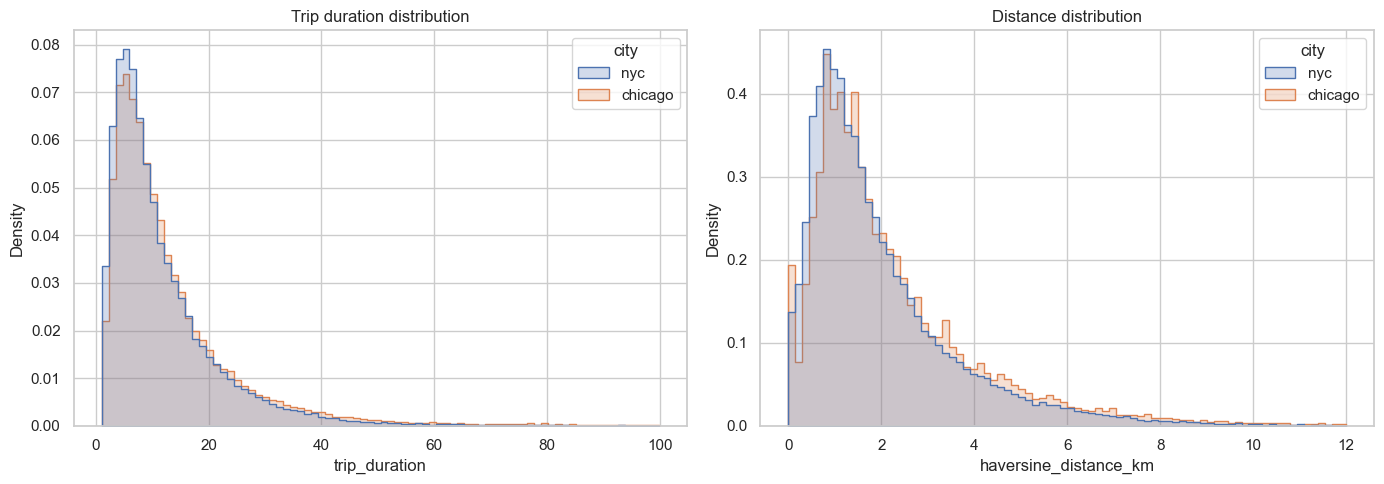

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=sample_df, x="trip_duration", hue="city", bins=80, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Trip duration distribution")

sns.histplot(data=sample_df, x="haversine_distance_km", hue="city", bins=80, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Distance distribution")

plt.tight_layout()

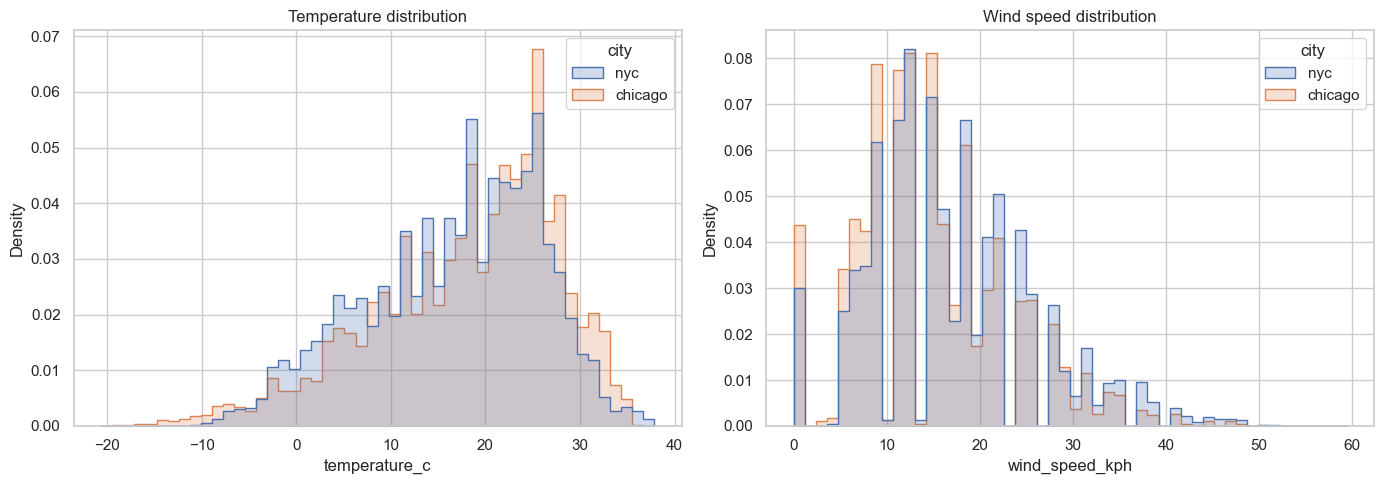

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=sample_df, x="temperature_c", hue="city", bins=50, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Temperature distribution")

sns.histplot(data=sample_df, x="wind_speed_kph", hue="city", bins=50, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Wind speed distribution")

plt.tight_layout()

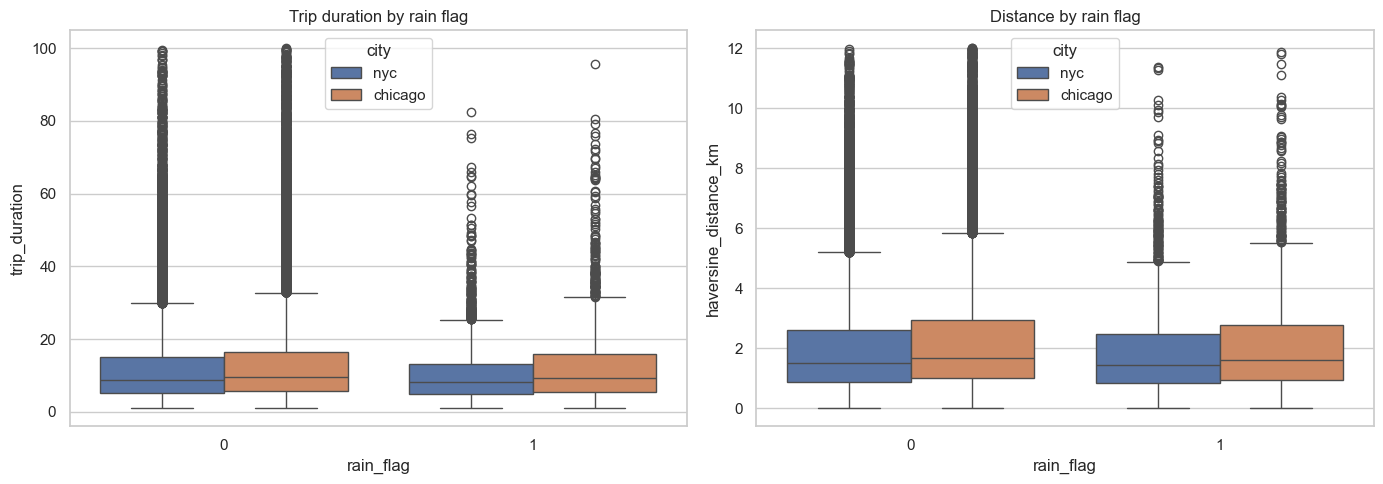

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sample_df, x="rain_flag", y="trip_duration", hue="city", ax=axes[0])
axes[0].set_title("Trip duration by rain flag")

sns.boxplot(data=sample_df, x="rain_flag", y="haversine_distance_km", hue="city", ax=axes[1])
axes[1].set_title("Distance by rain flag")

plt.tight_layout()

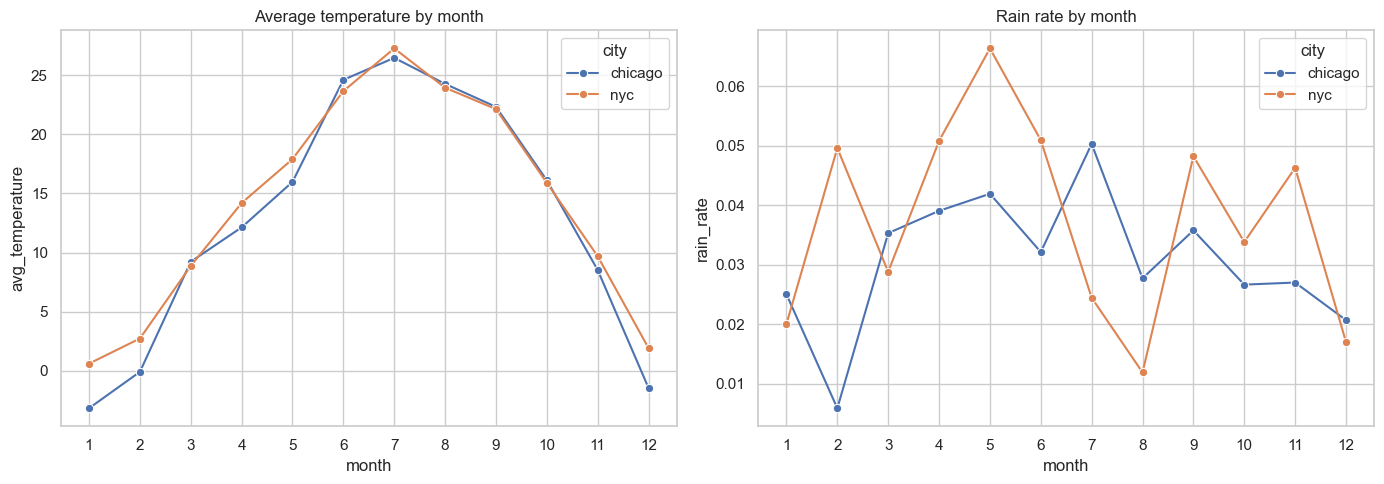

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=monthly, x="month", y="avg_temperature", hue="city", marker="o", ax=axes[0])
axes[0].set_title("Average temperature by month")
axes[0].set_xticks(range(1, 13))

sns.lineplot(data=monthly, x="month", y="rain_rate", hue="city", marker="o", ax=axes[1])
axes[1].set_title("Rain rate by month")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()

## 11. Correlations

This is a quick sanity check, not a causal analysis.

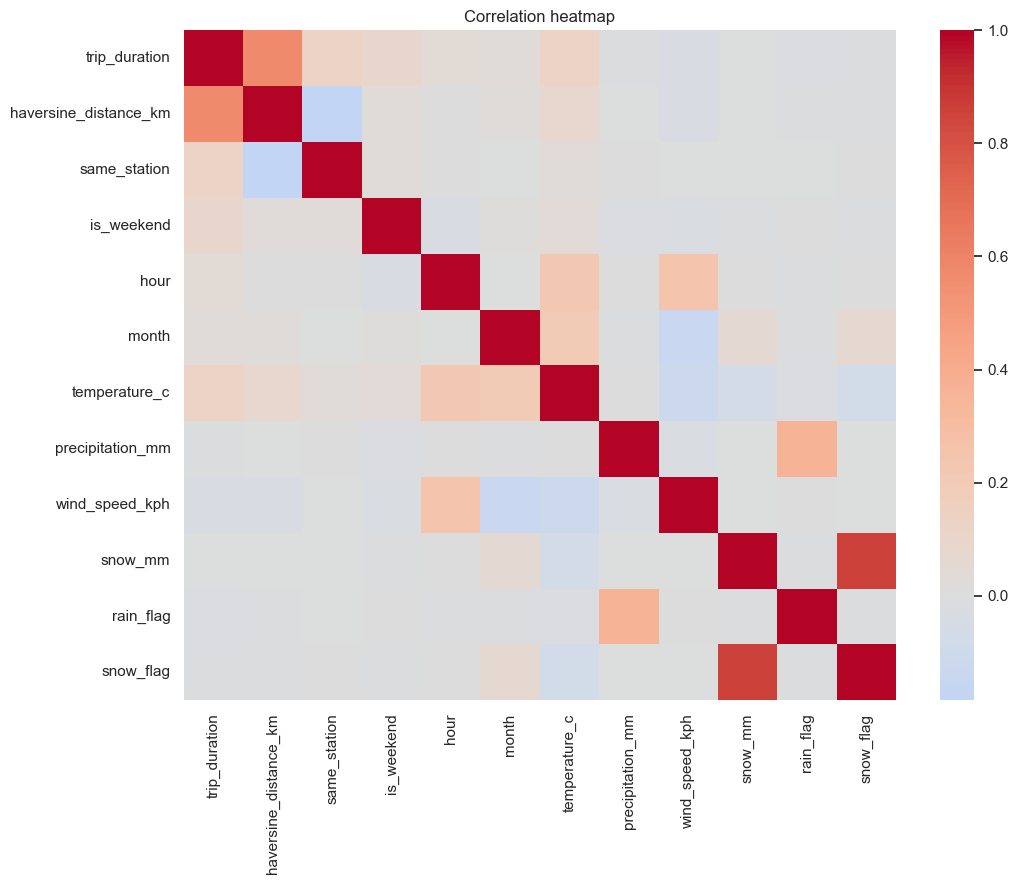

In [22]:
corr_cols = [
    "trip_duration",
    "haversine_distance_km",
    "same_station",
    "is_weekend",
    "hour",
    "month",
    "temperature_c",
    "precipitation_mm",
    "wind_speed_kph",
    "snow_mm",
    "rain_flag",
    "snow_flag",
]

corr = sample_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()